<a href="https://colab.research.google.com/github/CarlitosDamm/Hackaton/blob/main/Clasificacion_de_calidad_de_vinos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

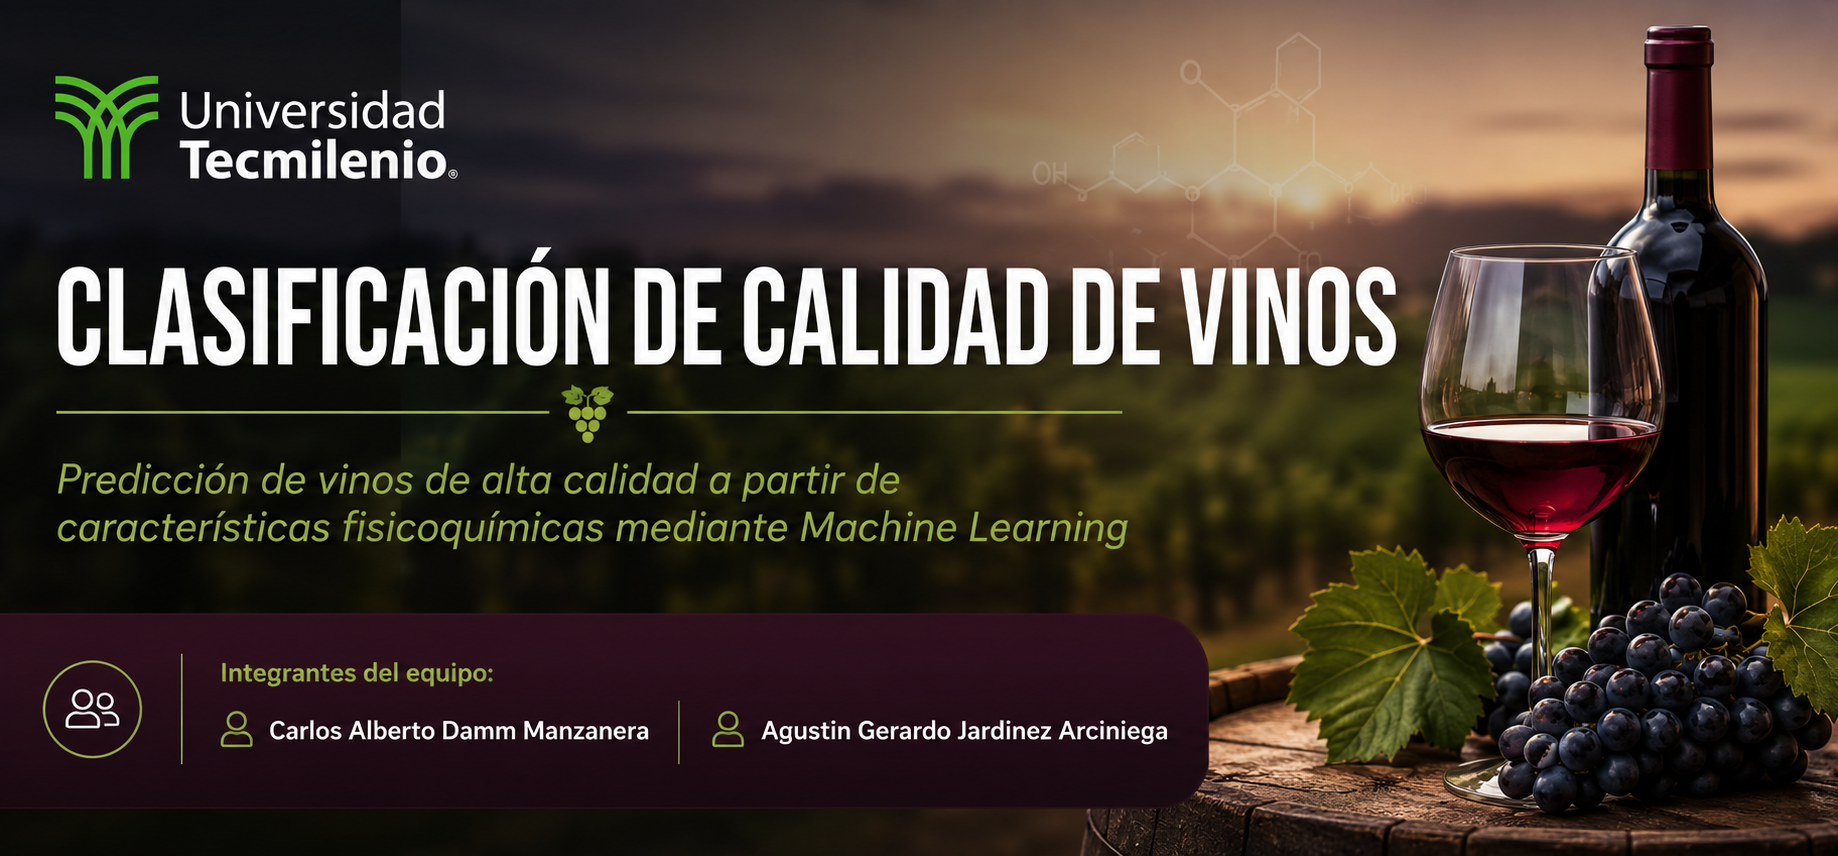

# Clasificación de Calidad de Vinos

**Objetivo del proyecto:**  
Predecir si un vino puede clasificarse como de alta calidad a partir de sus características fisicoquímicas.

**Contexto:**  
Este proyecto se plantea como un problema de control de calidad en la industria alimentaria. A partir de mediciones de laboratorio del vino, se busca apoyar la toma de decisiones sobre si un lote puede considerarse de alta calidad.

**Dataset:** Wine Quality Dataset - UCI Machine Learning Repository.  
**Modelos:** Regresión Logística, Árbol de Decisión y Random Forest.  
**Métricas:** Accuracy, Precision, Recall, F1-score, Especificidad, ROC-AUC.

In [ ]:
# Importar librerias

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Generar carpetas de salida para guardar los resultados y gráficas para el dashboard
os.makedirs("Imagenes", exist_ok=True)
os.makedirs("Resultados", exist_ok=True)
os.makedirs("Dashboard", exist_ok=True)

# 2. Carga del dataset

Se utilizarán las dos bases del Wine Quality Dataset: vino tinto y vino blanco.  
Se agrega una variable llamada `wine_type` para indicar si el registro corresponde a vino tinto o blanco.

In [ ]:
# Se carga el dataset

red_wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
white_wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

red_wine = pd.read_csv(red_wine_url, sep=";")
white_wine = pd.read_csv(white_wine_url, sep=";")

# Se agrega una columna nueva donde se categorizan los vinos en rojos y blancos
red_wine["wine_type"] = 0    # 0 = vino tinto
white_wine["wine_type"] = 1  # 1 = vino blanco

# Se juntan los dataset para manejar uno solo
df = pd.concat([red_wine, white_wine], axis=0).reset_index(drop=True)

print("Dimensiones del dataset:", df.shape)
display(df.head())

# 3. Exploración inicial del dataset

Como parte de buenas practicas, en esta sección se revisan los datos como las dimensiones, tipos de datos, valores nulos, estadísticas descriptivas y distribución de la variable original `quality`.

In [ ]:
# Se imprime la informacion para el analisis posterior

print("Información general del dataset:")
display(df.info())

print("\nEstadísticas descriptivas:")
display(df.describe())

print("\nValores nulos por columna:")
display(df.isnull().sum())

print("\nDistribución de la variable quality:")
display(df["quality"].value_counts().sort_index())

In [ ]:
# Se genera una gráfica con la distribución de la calidad original y se guarda en el folder creado anteriormente

plt.figure(figsize=(8, 5))
df["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de la calidad original del vino")
plt.xlabel("Calidad")
plt.ylabel("Número de muestras")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("Imagenes/distribucion_quality.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. Transformación a problema de clasificación binaria

El dataset original califica los vinos con valores numéricos de calidad.  
Para este proyecto se transforma el problema a clasificación binaria, donde:

- `0 = Calidad estándar`: vinos con `quality < 7`
- `1 = Alta calidad`: vinos con `quality >= 7`

Esto nos permite evaluar el modelo con la matriz de confusión y las metricas como: precision, recall, F1-score, ROC-AUC y ajuste de umbral.

In [ ]:
# Se declara la variable objetivo binaria donde cualquier vino con una calidad mayor o igual a 7 es considerado de alta calidad y cualquiera con menor a 7 es estandar

df["high_quality"] = np.where(df["quality"] >= 7, 1, 0)

# Se muestra la nueva distribicion con nuestro variable objetivo binaria
print("Distribución de la variable objetivo binaria:")
display(df["high_quality"].value_counts())

# Se agrega una visualizacion con porcentaje
print("\nPorcentaje por clase:")
display((df["high_quality"].value_counts(normalize=True) * 100).round(2))

In [ ]:
# Se genera una nueva gráfica con la nueva distribución de clase binaria y se guarda la nueva grafica en la misma carpeta

plt.figure(figsize=(6, 5))
df["high_quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de clases: calidad estándar vs alta calidad")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.xticks(ticks=[0, 1], labels=["Estándar", "Alta calidad"], rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("Imagenes/distribucion_clases.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Preparación de variables y división Train/Test

Se separan las variables predictoras de la variable objetivo.  
La variable `quality` original se elimina para evitar fuga de información, porque `high_quality` fue creada directamente a partir de ella.

In [ ]:
# Separamos nuestro dataset en datos o caracteristicas y la categoria a la que pertenecen, removemos la columna original de quality para evitar que se detecte el patron linear de >=7.

X = df.drop(columns=["quality", "high_quality"])
y = df["high_quality"]

# Preparamos los datos para poder usarlos en el entrenamiento
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Visualizamos los tamanos para validar que ambas categorias estan bien representadas
print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

print("\nDistribución en entrenamiento:")
display(y_train.value_counts(normalize=True).round(4))

print("\nDistribución en prueba:")
display(y_test.value_counts(normalize=True).round(4))

# 6. Entrenamiento de modelos

Se entrenan tres modelos:

1. **Regresión Logística**: baseline solicitado por la actividad.
2. **Árbol de Decisión**: modelo interpretable de comparación.
3. **Random Forest**: modelo candidato principal.

Como nota adicional, la Regresión Logística usa estandarización porque es sensible a la escala de las variables. Los modelos basados en árboles no requieren escalamiento de variables.

In [ ]:
# Definimos los modelos y su hyperparametros de entrenamiento

models = {
    "Logistic Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )
}

# Se entrena cada modelo con la particion establecida anteriormente
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Modelo entrenado: {name}")

# 7. Evaluación inicial con umbral 0.50

Se evalúan los modelos usando el umbral estándar de clasificación de 0.50.  
Esto significa que si la probabilidad predicha de que el vino sea de alta calidad es mayor o igual a 0.50, el vino se clasifica como de alta calidad.

In [ ]:
# Se declaran las funciones para evaluar al modelo

# Se calcula la especifidad, o cuantos vinos estandar realmente detecto como standar
def calculate_specificity(y_true, y_pred):
    """Calcula la especificidad: TN / (TN + FP)."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)


def evaluate_model(name, model, X_test, y_test, threshold=0.50):
    """Evalúa un modelo usando un umbral específico."""
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "specificity": calculate_specificity(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

    return metrics

# Se declara una variable para almacenar los resultados de los modelos con fines comparativos
metrics_list = []

# Se actualiza la variable con los resultados
for name, model in models.items():
    metrics_list.append(evaluate_model(name, model, X_test, y_test, threshold=0.50))

metrics_df = pd.DataFrame(metrics_list)
metrics_df_rounded = metrics_df.copy()
numeric_cols = metrics_df_rounded.select_dtypes(include=[np.number]).columns
metrics_df_rounded[numeric_cols] = metrics_df_rounded[numeric_cols].round(4)

display(metrics_df_rounded)

metrics_df_rounded.to_csv("Resultados/model_metrics_threshold_050.csv", index=False)

In [ ]:
# Se genera una gráfica para comparar las métricas principales

plot_metrics = metrics_df.set_index("model")[["accuracy", "precision", "recall", "f1_score", "roc_auc"]]

plt.figure(figsize=(10, 6))
plot_metrics.plot(kind="bar", figsize=(10, 6))
plt.title("Comparación de modelos con umbral 0.50")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("Imagenes/comparacion_modelos_threshold_050.png", dpi=300, bbox_inches="tight")
plt.show()

# 8. Matriz de confusión del mejor modelo inicial

Se selecciona el modelo con mayor F1-score como mejor modelo inicial.  
La matriz de confusión permite interpretar errores de clasificación:

- **TN:** vinos estándar clasificados correctamente.
- **FP:** vinos estándar clasificados incorrectamente como alta calidad.
- **FN:** vinos de alta calidad clasificados incorrectamente como estándar.
- **TP:** vinos de alta calidad clasificados correctamente.

In [ ]:
# Se obtiene el mejor modelo filtrando los valores de mayor a menor en base al f1_score

best_initial_model_name = metrics_df.sort_values("f1_score", ascending=False).iloc[0]["model"]
best_initial_model = models[best_initial_model_name]

y_proba_initial = best_initial_model.predict_proba(X_test)[:, 1]
y_pred_initial = (y_proba_initial >= 0.50).astype(int)

print("Mejor modelo inicial según F1-score:", best_initial_model_name)
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_initial, target_names=["Estándar", "Alta calidad"]))

cm = confusion_matrix(y_test, y_pred_initial)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Estándar", "Alta calidad"]
)

# Se almancena la matriz de confusion en la carpeta de imagenes
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
plt.title(f"Matriz de confusión - {best_initial_model_name} - Umbral 0.50")
plt.tight_layout()
plt.savefig("Imagenes/matriz_confusion_threshold_050.png", dpi=300, bbox_inches="tight")
plt.show()

# 9. Validación cruzada

La validación cruzada permite revisar si el desempeño del modelo es estable en distintas particiones del dataset, ya que en algunos casos el resultado depende de el tipo de particion y esto nos asegura que el modelo tendra el mismo desempeno aunque el dataset sea diferente.  
Se utiliza Stratified K-Fold para conservar la proporción de clases en cada partición.

In [ ]:
# Se delcara una particion de 5 para generar 5 divisiones del dataset original, el cual sera entrenado y probado con 5 diferentes particiones

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# Se declara una variable para almacenar los resultados
cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    for metric_name in scoring.keys():
        cv_results.append({
            "model": name,
            "metric": metric_name,
            "mean": scores[f"test_{metric_name}"].mean(),
            "std": scores[f"test_{metric_name}"].std()
        })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df_rounded = cv_results_df.copy()
cv_results_df_rounded[["mean", "std"]] = cv_results_df_rounded[["mean", "std"]].round(4)
# Se muestran los resultados
display(cv_results_df_rounded)
# Se guardan los resultados dentro de la carpeta
cv_results_df_rounded.to_csv("Resultados/cross_validation_results.csv", index=False)

In [ ]:
# Se genera una gráfica con las metricas F1 y ROC-AUC promedio en validación cruzada

cv_pivot = cv_results_df.pivot(index="model", columns="metric", values="mean")

# Se muestra la grafica y se guarda dentro de la carpeta de imagenes para el dashboard
plt.figure(figsize=(8, 5))
cv_pivot[["f1", "roc_auc"]].plot(kind="bar", figsize=(8, 5))
plt.title("Validación cruzada: F1 y ROC-AUC promedio")
plt.xlabel("Modelo")
plt.ylabel("Promedio")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("Imagenes/validacion_cruzada_f1_auc.png", dpi=300, bbox_inches="tight")
plt.show()

# 10. Curva ROC y AUC

La curva ROC muestra la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos para distintos umbrales.  
El AUC resume la capacidad del modelo para separar las clases: mientras más cercano a 1, mejor.

In [ ]:
# Se genera una imagen para visualizar la curva

plt.figure(figsize=(8, 6))

roc_data = []

# Para cada modelo, se obtienen las metricas que seran usadas para mostrar en la grafica
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_value = roc_auc_score(y_test, y_proba)

    roc_data.append({
        "model": name,
        "roc_auc": auc_value
    })

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_value:.3f})")

# Se muestra la grafica y se almacena dentro de la carpeta de imagenes para el dashboard
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.title("Curva ROC por modelo")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Imagenes/curva_roc_modelos.png", dpi=300, bbox_inches="tight")
plt.show()

# Se guardan los resultados dentro de la carpeta de resultados
roc_df = pd.DataFrame(roc_data)
display(roc_df.round(4))
roc_df.round(4).to_csv("Resultados/roc_auc_results.csv", index=False)

# 11. Ajuste de umbral

El umbral por defecto de 0.50 no siempre es el mejor, asi que solo se usa como punto de partida, dependiendo de las metricas podemos observar si es que se estan perdiendo vinos buenos o si al contrario, se estan declarando vinos estandar como buenos, y de ahi mover el umbral hacia arriba o hacia abajo para compensar.

En este proyecto se buscará el umbral que maximice el F1-score del mejor modelo inicial.

El F1-score balancea precision y recall, lo cual es útil cuando existe desbalance de clases.

In [ ]:
# Se utiliza el mejor modelo inicial según F1-score
final_model_name = best_initial_model_name
final_model = best_initial_model

y_proba_final = final_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_final)

# Se declara una variable para guardar los resultados
threshold_results = []


for threshold in thresholds:
    y_pred_threshold = (y_proba_final >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "specificity": calculate_specificity(y_test, y_pred_threshold),
        "f1_score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

# Se almacenan los resultados en un dataframe
threshold_df = pd.DataFrame(threshold_results)

# Se obtiene el mejor f1_score ordenandolos de mayor a menor
best_threshold_row = threshold_df.sort_values("f1_score", ascending=False).iloc[0]
best_threshold = best_threshold_row["threshold"]

# Se muestran el mejor modelo y su mejor umbral
print("Modelo usado para ajuste de umbral:", final_model_name)
print("Mejor umbral según F1-score:", round(best_threshold, 4))
display(best_threshold_row.to_frame().T.round(4))

# Se guardan los resultados en la carpeta correspondiente
threshold_df.round(4).to_csv("Resultados/threshold_analysis.csv", index=False)

In [ ]:
# Se genera una gráfica con las metricas de Precision, Recall y F1 por umbral

plt.figure(figsize=(9, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], label="F1-score")
plt.axvline(best_threshold, linestyle="--", label=f"Umbral óptimo = {best_threshold:.3f}")

# Se muestra la grafica y se guarda en la carpeta de imagenes
plt.title(f"Ajuste de umbral - {final_model_name}")
plt.xlabel("Umbral")
plt.ylabel("Métrica")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Imagenes/ajuste_umbral_precision_recall_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Matriz de confusión con umbral optimizado

y_pred_optimized = (y_proba_final >= best_threshold).astype(int)

cm_optimized = confusion_matrix(y_test, y_pred_optimized)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_optimized,
    display_labels=["Estándar", "Alta calidad"]
)

# Se genera la imagen y se guarda en la carpeta
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
plt.title(f"Matriz de confusión - {final_model_name} - Umbral optimizado")
plt.tight_layout()
plt.savefig("Imagenes/matriz_confusion_threshold_optimizado.png", dpi=300, bbox_inches="tight")
plt.show()

optimized_metrics = evaluate_model(final_model_name, final_model, X_test, y_test, threshold=best_threshold)
display(pd.DataFrame([optimized_metrics]).round(4))

# 12. Pruebas A/B simuladas

Se simula una prueba A/B comparando dos estrategias de decisión:

- **Grupo A:** modelo con umbral estándar de 0.50.
- **Grupo B:** mismo modelo con umbral optimizado.

El objetivo es observar cómo cambia la cantidad de falsos negativos, falsos positivos, recall y especificidad.

In [ ]:
# Se define la funcion para agrupar los resultados obtenidos anteriormente

def ab_group_results(group_name, threshold):
    y_pred = (y_proba_final >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        "group": group_name,
        "threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "specificity": calculate_specificity(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred, zero_division=0)
    }

ab_results = [
    ab_group_results("Grupo A - Umbral 0.50", 0.50),
    ab_group_results("Grupo B - Umbral optimizado", best_threshold)
]

ab_df = pd.DataFrame(ab_results)
ab_df_rounded = ab_df.copy()
ab_df_rounded[["threshold", "accuracy", "precision", "recall", "specificity", "f1_score"]] = (
    ab_df_rounded[["threshold", "accuracy", "precision", "recall", "specificity", "f1_score"]].round(4)
)

display(ab_df_rounded)

# Se guardan los resultados en la carpeta
ab_df_rounded.to_csv("Resultados/ab_testing_results.csv", index=False)

In [ ]:
# Se genera una gráfica para mostrar la comparación A/B

ab_plot = ab_df.set_index("group")[["FP", "FN", "recall", "specificity"]]

fig, ax1 = plt.subplots(figsize=(10, 6))

ab_df.set_index("group")[["FP", "FN"]].plot(kind="bar", ax=ax1)
ax1.set_title("Prueba A/B simulada: umbral 0.50 vs umbral optimizado")
ax1.set_xlabel("Grupo")
ax1.set_ylabel("Número de errores")
ax1.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("Imagenes/prueba_ab_fp_fn.png", dpi=300, bbox_inches="tight")
plt.show()

# Se muestra la grafica y se guarda en la carpeta de imagenes
plt.figure(figsize=(8, 5))
ab_df.set_index("group")[["recall", "specificity"]].plot(kind="bar", figsize=(8, 5))
plt.title("Prueba A/B simulada: Recall vs Especificidad")
plt.xlabel("Grupo")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("Imagenes/prueba_ab_recall_specificity.png", dpi=300, bbox_inches="tight")
plt.show()

# 13. Selección del modelo final

El modelo final se selecciona considerando:

- desempeño en F1-score;
- ROC-AUC;
- estabilidad en validación cruzada;
- comportamiento al ajustar el umbral;
- balance entre falsos positivos y falsos negativos.

La elección final puede ajustarse de acuerdo con el objetivo del negocio:

- Si se desea evitar vender vinos estándar como si fueran premium, conviene priorizar precision.
- Si se desea detectar la mayor cantidad posible de vinos de alta calidad, conviene priorizar recall.
- Si se busca equilibrio, F1-score es una buena métrica de referencia.

In [ ]:
# Resumen final del mejor modelo

final_summary = pd.DataFrame([
    {
        "selected_model": final_model_name,
        "default_threshold": 0.50,
        "optimized_threshold": best_threshold,
        "default_f1": metrics_df.loc[metrics_df["model"] == final_model_name, "f1_score"].values[0],
        "optimized_f1": optimized_metrics["f1_score"],
        "roc_auc": optimized_metrics["roc_auc"],
        "default_recall": metrics_df.loc[metrics_df["model"] == final_model_name, "recall"].values[0],
        "optimized_recall": optimized_metrics["recall"],
        "default_specificity": metrics_df.loc[metrics_df["model"] == final_model_name, "specificity"].values[0],
        "optimized_specificity": optimized_metrics["specificity"]
    }
])

# Se guardan los resultados
display(final_summary.round(4))
final_summary.round(4).to_csv("Resultados/final_model_summary.csv", index=False)

# 14. Dashboard visual de resultados

Esta sección genera una imagen resumen para usar en la carpeta `dashboard/`.

In [ ]:
# Métricas principales del modelo final optimizado
dashboard_metrics = {
    "Accuracy": optimized_metrics["accuracy"],
    "Precision": optimized_metrics["precision"],
    "Recall": optimized_metrics["recall"],
    "F1-score": optimized_metrics["f1_score"],
    "ROC-AUC": optimized_metrics["roc_auc"]
}

dashboard_df = pd.DataFrame({
    "Metric": list(dashboard_metrics.keys()),
    "Value": list(dashboard_metrics.values())
})

plt.figure(figsize=(10, 6))
plt.bar(dashboard_df["Metric"], dashboard_df["Value"])
plt.title(f"Métricas clave del modelo final: {final_model_name}")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

for index, row in dashboard_df.iterrows():
    plt.text(index, row["Value"] + 0.02, f"{row['Value']:.3f}", ha="center")

plt.tight_layout()
plt.savefig("Dashboard/metricas_clave_modelo_final.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Imagen resumen tipo dashboard

fig = plt.figure(figsize=(14, 10))

# 1. Métricas clave
ax1 = fig.add_subplot(2, 2, 1)
ax1.bar(dashboard_df["Metric"], dashboard_df["Value"])
ax1.set_title(f"Métricas clave - {final_model_name}")
ax1.set_ylim(0, 1)
ax1.grid(axis="y", alpha=0.3)
for index, row in dashboard_df.iterrows():
    ax1.text(index, row["Value"] + 0.02, f"{row['Value']:.2f}", ha="center", fontsize=9)

# 2. ROC
ax2 = fig.add_subplot(2, 2, 2)
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_value = roc_auc_score(y_test, y_proba)
    ax2.plot(fpr, tpr, label=f"{name} ({auc_value:.2f})")
ax2.plot([0, 1], [0, 1], linestyle="--", label="Aleatorio")
ax2.set_title("Curva ROC")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# 3. Matriz de confusión
ax3 = fig.add_subplot(2, 2, 3)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_optimized,
    display_labels=["Estándar", "Alta calidad"]
)
disp.plot(ax=ax3, values_format="d", colorbar=False)
ax3.set_title("Matriz de confusión - Umbral optimizado")

# 4. Comparación de modelos
ax4 = fig.add_subplot(2, 2, 4)
plot_metrics[["f1_score", "roc_auc"]].plot(kind="bar", ax=ax4)
ax4.set_title("Comparación de modelos")
ax4.set_xlabel("Modelo")
ax4.set_ylabel("Valor")
ax4.set_ylim(0, 1)
ax4.tick_params(axis="x", rotation=0)
ax4.grid(axis="y", alpha=0.3)
ax4.legend(fontsize=8)

plt.suptitle("Wine Quality Classification - Dashboard de Resultados", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("Dashboard/dashboard_resumen.png", dpi=300, bbox_inches="tight")
plt.show()